진행 방식  
1. 데이터 탐색 (EDA)     → 데이터가 어떻게 생겼는지 파악
2. 전처리               → 결측값, 이상치, 인코딩
3. 피처 엔지니어링       → 새로운 변수 만들기
4. 모델 학습 + 비교      → 여러 모델 돌려보기
5. 튜닝 + 최종 평가      → Grid Search + 교차검증
6. 결과 해석            → 숫자가 아닌 의미로 설명

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing(as_frame=True)
df = data.frame

print(df.shape)
print(df.head())
print(df.describe())
print(df.isnull().sum())

(20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154 

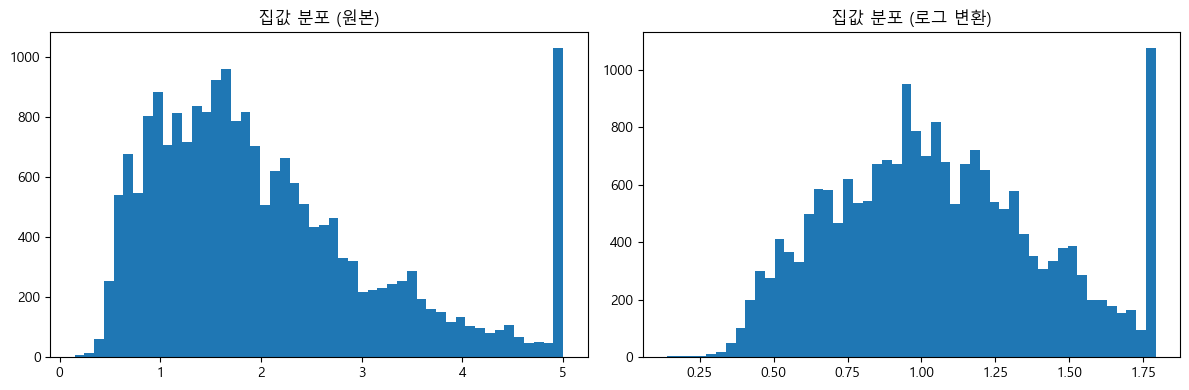

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
# 마이너스 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 1. 집값 분포 시각화
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(df['MedHouseVal'], bins=50)
plt.title('집값 분포 (원본)')

plt.subplot(1, 2, 2)
plt.hist(np.log1p(df['MedHouseVal']), bins=50)
plt.title('집값 분포 (로그 변환)')
plt.tight_layout()
plt.show()

원본: 20640개 -> 정제 후: 17293개


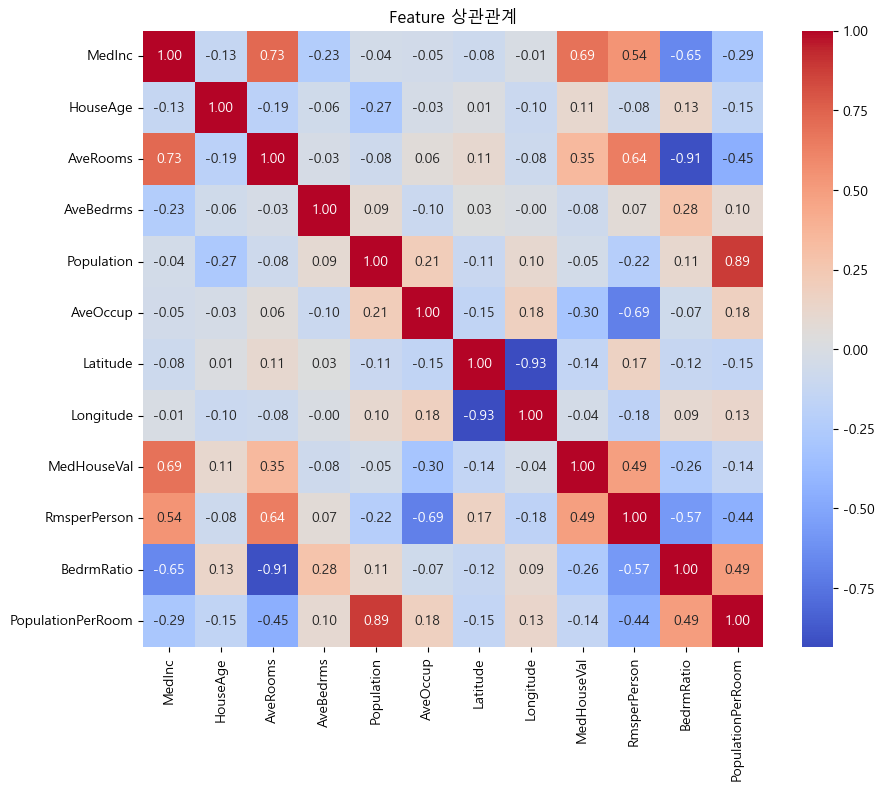

In [14]:
# 2. 이상치 제거 함수
def remove_outliers(df, columns):
    df_clean = df.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        df_clean = df_clean[(df_clean[col] >= Q1 - (IQR * 1.5)) & (df_clean[col] <= Q3 + (IQR * 1.5))]
    return df_clean

df_clean = remove_outliers(df, ['AveRooms', 'AveBedrms', 'AveOccup', 'Population'])
print(f"원본: {len(df)}개 -> 정제 후: {len(df_clean)}개")

# 3. 피처 엔지니어링 
df_clean['RmsperPerson'] = np.array(df_clean['AveRooms']) / np.array(df_clean['AveOccup'])
df_clean['BedrmRatio'] = np.array(df_clean['AveBedrms']) / np.array(df_clean['AveRooms'])
df_clean['PopulationPerRoom'] = np.array(df_clean['Population']) / np.array(df_clean['AveRooms'])

# 상관관계 히트맴
plt.figure(figsize=(10, 8))
sns.heatmap(df_clean.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature 상관관계')
plt.show()

In [21]:
# 모델 학습 + 비교
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 피쳐 / 타것 분리
x = df_clean.drop('MedHouseVal', axis=1)
y = df_clean['MedHouseVal']

# train / test 분리 + 정규화
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
x_train_s = scaler.fit_transform(x_train)
x_test_s = scaler.transform(x_test)

# 3개 모델 딕셔너리로 관리
models = {
    'Linear' : LinearRegression(),
    'random_f' : RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost' : XGBRegressor(eval_metric='rmse', random_state=42)
}

# 각 모델 학습 + 평가
for name, model in models.items():
    model.fit(x_train_s, y_train)
    pred = model.predict(x_test_s)
    rmse = np.sqrt(mean_squared_error(pred, y_test))
    r2 = r2_score(pred, y_test)
    print(f"{name:12s}  RMSE: {rmse:.3f}  R²: {r2:.3f}")


Linear        RMSE: 0.647  R²: 0.543
random_f      RMSE: 0.498  R²: 0.752
XGBoost       RMSE: 0.460  R²: 0.814


In [24]:
# Grid Search로 XGBoost tuning
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth' : [3, 5, 7],
    'learning_rate': [0.05, 0.1]
}
# GridSearchCV 설정 
grid = GridSearchCV(
    XGBRegressor(eval_metric='rmse', random_state=42),
    param_grid,
    cv = 5,
    scoring='neg_root_mean_squared_error'
)
grid.fit(x_train_s, y_train)

print(f"최적 파라미터: {grid.best_params_}")
print(f"최적 RMSE:    {-grid.best_score_:.3f}")

# 최적 모델로 최종 평가
best_model = grid.best_estimator_
pred_best = best_model.predict(x_test_s)
rmse_best = np.sqrt(mean_squared_error(pred_best, y_test))
r2_best = r2_score(pred_best, y_test)

print(f"\n튜닝 전 XGBoost  RMSE: 0.460  R²: 0.814")
print(f"튜닝 후 XGBoost  RMSE: {rmse_best:.3f}  R²: {r2_best:.3f}")

최적 파라미터: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}
최적 RMSE:    0.440

튜닝 전 XGBoost  RMSE: 0.460  R²: 0.814
튜닝 후 XGBoost  RMSE: 0.446  R²: 0.821


### 고도화
1. 로그 변환 타겟
- 대부분 모델은 균등하게 분포된 타겟일 때 더 잘 작동

In [29]:
# train/test 분리 (df_clean, x_train_s, x_test_s 그대로 사용)
y_log = np.log1p(y)
x_train, x_test, y_train_log, y_test_log = train_test_split(
    x, y_log, test_size=0.2, random_state=42
)

# scale
scaler = StandardScaler()
x_train_s = scaler.fit_transform(x_train)
x_test_s = scaler.transform(x_test)

xgb_log = XGBRegressor(
    learning_rate=0.1,
    max_depth=7,
    n_estimators=200,
    eval_metric='rmse',
    random_state=42
)
xgb_log.fit(x_train_s, y_train_log)

# 예측 후 역변환
pred_log = xgb_log.predict(x_test_s)
pred_original = np.expm1(pred_log)

rmse_log = np.sqrt(mean_squared_error(y_test, pred_original))
r2_log = r2_score(y_test, pred_original)
print(f"로그 변환 전  RMSE: 0.446  R²: 0.821")
print(f"로그 변환 후  RMSE: {rmse_log:.3f}  R²: {r2_log:.3f}")

로그 변환 전  RMSE: 0.446  R²: 0.821
로그 변환 후  RMSE: 0.449  R²: 0.847


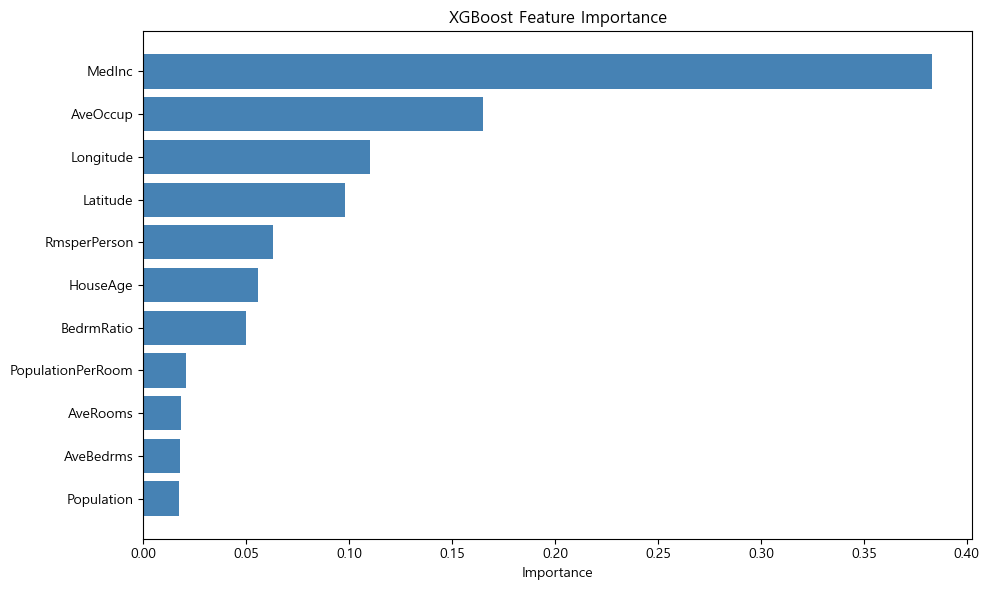

              feature  importances
0              MedInc     0.383289
5            AveOccup     0.165084
7           Longitude     0.110287
6            Latitude     0.097753
8        RmsperPerson     0.063031
1            HouseAge     0.055812
9          BedrmRatio     0.050086
10  PopulationPerRoom     0.020717
2            AveRooms     0.018415
3           AveBedrms     0.018012
4          Population     0.017515


In [31]:
# Feature Importance 시각화

import matplotlib.pyplot as plt
import pandas as pd

# feature 이름 가져오기
feature_names = x.columns.tolist()

# XGBoost feature importance 추출
importances = best_model.feature_importances_

# 데이터프레임으로 정리 + 정렬
fi_df = pd.DataFrame({
    'feature': feature_names,
    'importances': importances
}).sort_values('importances', ascending=False)

# 시각화
plt.figure(figsize=(10, 6))
plt.barh(fi_df['feature'], fi_df['importances'], color='steelblue')
plt.xlabel('Importance')
plt.title('XGBoost Feature Importance')
plt.gca().invert_yaxis()  # 중요한 것이 위에 오도록
plt.tight_layout()
plt.show()

print(fi_df)

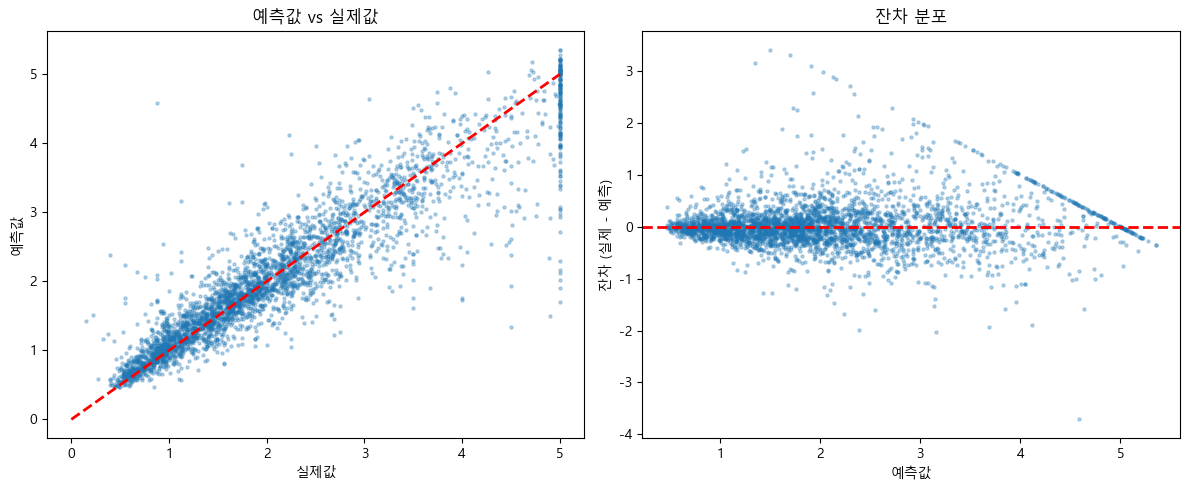

잔차 평균: 0.021
잔차 std:  0.449


In [32]:
# 예측값 vs 실제값 시각화
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, pred_original, alpha=0.3, s=5)
plt.plot([0, 5], [0, 5], 'r--', linewidth=2)
plt.xlabel('실제값')
plt.ylabel('예측값')
plt.title('예측값 vs 실제값')

residuals = np.array(y_test) - pred_original
plt.subplot(1, 2, 2)
plt.scatter(pred_original, residuals, alpha=0.3, s=5)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('예측값')
plt.ylabel('잔차 (실제 - 예측)')
plt.title('잔차 분포')
plt.tight_layout()
plt.show()

print(f"잔차 평균: {residuals.mean():.3f}")
print(f"잔차 std:  {residuals.std():.3f}")